[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1NXw5moixEiQCddNd-k6ooLskie6zrGvH#scrollTo=Sv229JF7Zsx6)

# **LIGHT GRADIENT BOOSTING MACHINE MODEL**


In [ ]:
# Libraries used in this model
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFECV

## READING AND PRE-PROCESSING THE INITIAL DATASET

In [ ]:
#1. INITIAL READING
df=pd.read_csv("https://raw.githubusercontent.com/jfelipevasquez/Forecasting-electricity-production-Kaggle/refs/heads/main/dataset/train.csv")
df_1 = df.copy()
df_1.drop(columns=['ID', 'day', 'sunrise', 'sunset','capacity_clipped'], inplace=True) ## São eliminadas colunas que não aportam ao problema

df_1['data'] = pd.to_datetime(df_1['start'])
df_1 = df_1.sort_values('data').reset_index(drop=True)

# Extraction of month (1–12), day (1–366), and hour (0–23)
df_1['mes'] = df_1['data'].dt.month
df_1['dia_ano'] = df_1['data'].dt.dayofyear
df_1['hora'] = df_1['data'].dt.hour

df_1.drop(columns=['start', 'time_hourly' ], inplace=True) ## Elimination of time columns

# Transformation of time periods into cyclic variables
periodo_hora = 24
periodo_mes = 12
periodo_dia_ano = 365

# Transformation for 'hour'
df_1['hora_sin'] = np.sin(2 * np.pi * df_1['hora'] / periodo_hora)
df_1['hora_cos'] = np.cos(2 * np.pi * df_1['hora'] / periodo_hora)
# Transformation for 'month'
df_1['mes_sin'] = np.sin(2 * np.pi * df_1['mes'] / periodo_mes)
df_1['mes_cos'] = np.cos(2 * np.pi * df_1['mes'] / periodo_mes)
# Transformation for 'dia_ano'
df_1['dia_ano_sin'] = np.sin(2 * np.pi * df_1['dia_ano'] / periodo_dia_ano)
df_1['dia_ano_cos'] = np.cos(2 * np.pi * df_1['dia_ano'] / periodo_dia_ano)

# If it is nighttime (solar altitude <= 0), the actual training output should be 0.
df_1['kw'] = np.where(df_1['altitude'] <= 0, 0, df_1['kw'])

# There are no negative real productions
df_1['kw'] = np.where(df_1['kw'] < 0, 0, df_1['kw'])

# It is not possible to exceed the maximum installed capacity (468 kW)
df_1['kw'] = np.where(df_1['kw'] > 468, 468, df_1['kw'])

# Eliminate negative radiation before creating the physical variables
df_1['irradiation'] = np.where(df_1['irradiation'] < 0, 0, df_1['irradiation'])
df_1['S_d'] = np.where(df_1['S_d'] < 0, 0, df_1['S_d'])

# Effective radiation: the energy the panel can absorb (energy striking the panel's surface × the angle of incidence of the light on the panel)
df_1['GHI'] = df_1['irradiation'] * df_1['panel_cos']
df_1['DNI']=df_1["S_d"]*df_1["fold_cos"]

# Relate the time of year to the average temperature
df_1['efeito_estacao_temp'] = df_1['temp_total_mean'] * df_1['dia_ano_cos']

# Dense cloud cover index; low-level clouds are more detrimental to production than high-level clouds
df_1['nuvens_ponderadas'] = (df_1['cloud_low_mean'] * 1.0) + (df_1['cloud_mid_mean'] * 0.6) + (df_1['cloud_high_mean'] * 0.2)

# Production decreases as the panel temperature rises; irradiance is related to temperature
df_1['interacao_temp_irrad'] = df_1['irradiation'] * df_1['temp_total_mean']

# We define the condition using modified thresholds. It evaluates situations characterized by high radiation and low production
condicao_falha = (df_1['GHI'] >= 0.80) & (df_1['kw'] <= 60)

# We removed a few lines so they wouldn't confuse the model.
df_1 = df_1.drop(df_1[condicao_falha].index).reset_index(drop=True)


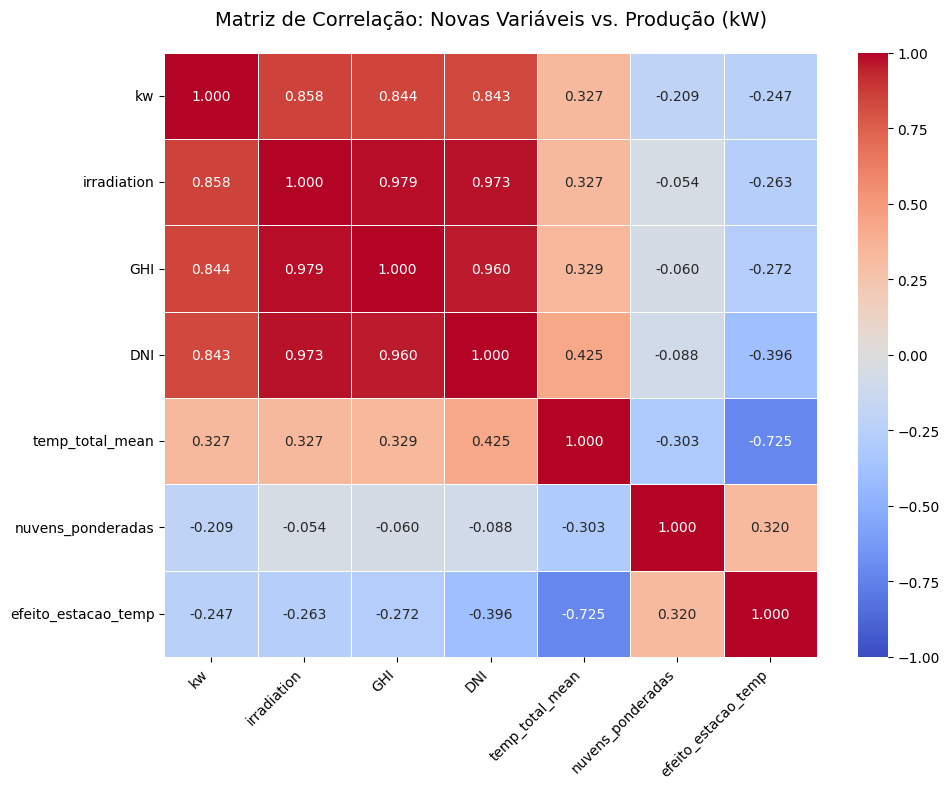

In [ ]:
# 2.  CORRELATION ANALYSIS OF THE NEW MACROCLIMATIC VARIAVLES
# We selected the new variables, the target variable, and the key physical reference variables
vars_analise = [
    'kw', 'irradiation', 'GHI','DNI',
    'temp_total_mean','nuvens_ponderadas',
    'efeito_estacao_temp'
]
# Calculates the Pearson correlation matrix
matriz_corr = df_1[vars_analise].corr()

# Configures and designs the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr,
    annot=True,          # Displays the numeric values ​​within each cell
    cmap='coolwarm',     # Color scale: blue (negative), white (zero), red (positive)
    fmt=".3f",           # Three decimal places for maximum precision
    linewidths=0.5,      # Subtle dividing line between the cells
    vmin=-1, vmax=1      # Strict limits of the Pearson correlation
)

plt.title('Matriz de Correlação: Novas Variáveis ​​vs. Produção (kW)', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Preparation of variables for the model

In [ ]:
# Characteristics (X) including climatic conditions missing data
features = [
    'S_d', 'airmass', 'altitude', 'azimuth', 'irradiation', 'fold_cos', 'panel_cos',
    'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'dia_ano_sin', 'dia_ano_cos',
    'temp_total_mean', 'cloud_total_mean', 'cloud_low_mean', 'cloud_high_mean', 'cloud_mid_mean',
    'GHI', 'nuvens_ponderadas', 'interacao_temp_irrad', 'DNI',
     'efeito_estacao_temp'
]

# Separate X and y
X = df_1[features]
y = df_1['kw']  # Objective variable

In [ ]:
# 3. Chronological breakdown—no cuts
x_train, x_test, y_train, y_test= train_test_split(X,y, test_size=0.2, shuffle=False)

# Initialize the indexes so that they start at 0
x_train = x_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## APPLICATION OF THE LIGHTGBM MODEL

In [ ]:
# 4. INITIAL BASELINE MODEL
LightGBM = LGBMRegressor(
    objective='regression_l1',  # This indicates that it optimizes for MAE
    max_depth=8,
    num_leaves=63,
    n_estimators=500,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.6,
    random_state=42,
    n_jobs=-1)

LightGBM.fit(x_train, y_train)

y_pred_LGB= LightGBM.predict(x_test)

mae_LGBM= mean_absolute_error(y_test, y_pred_LGB)
r2_LGBM = r2_score(y_test, y_pred_LGB)

print(f"MAE: {mae_LGBM:.2f}")
print(f"R2: {r2_LGBM:.3f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001725 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4869
[LightGBM] [Info] Number of data points in the train set: 18733, number of used features: 23
[LightGBM] [Info] Start training from score 6.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [ ]:
# 5. DEFINE TEMPORAL VALIDATOR
# CROSS-VALIDATION We defined a special validator for time series
tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(LightGBM, x_train, y_train, scoring="neg_mean_absolute_error", cv=tscv)
LGB_mae_scores = (-scores).round(3)

MAE_mean_LGB = np.mean(LGB_mae_scores.T)
print('MAE de cada Fold temporal:', LGB_mae_scores)
print('Promedio real del MAE temporal:', MAE_mean_LGB)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000729 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4458
[LightGBM] [Info] Number of data points in the train set: 3123, number of used features: 23
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

# FEATURE SELECTION BEFORE HYPERPARAMETER TUNING

##Feature importance

In [ ]:
# 6. Application of feature importance
# Extract the model's native gain
importancias_gain = LightGBM.booster_.feature_importance(importance_type='gain')

# Create the DataFrame and sort from highest to lowest
df_importancia = pd.DataFrame({
    'Variavel': features,
    'Ganho': importancias_gain
}).sort_values(by='Ganho', ascending=False).reset_index(drop=True)

df_importancia['Ganho'] = (df_importancia['Ganho'] / df_importancia['Ganho'].sum() * 100).map('{:.2f}%'.format)

# Show ranking
df_importancia

,Variavel,Ganho
0,S_d,36.22%
1,altitude,27.47%
2,airmass,11.77%
3,fold_cos,8.52%
4,DNI,3.89%
5,nuvens_ponderadas,1.38%
6,irradiation,1.33%
7,dia_ano_cos,1.33%
8,dia_ano_sin,1.26%
9,cloud_mid_mean,0.91%


##Permutation importance

In [ ]:
# 7. Calculate pure importance (sklearn delivery or positive MAE increment)
resultado_perm = permutation_importance(
    LightGBM,
    x_test,
    y_test,
    scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1
)

# Create the DataFrame and sort it by actual impact, from highest to lowest
df_perm = pd.DataFrame({
    'Variavel': features,
    'Impacto_MAE': resultado_perm.importances_mean
}).sort_values(by='Impacto_MAE', ascending=False).reset_index(drop=True)

# Directly convert the percentage within the same column
df_perm['Impacto_MAE'] = (df_perm['Impacto_MAE'] / df_perm['Impacto_MAE'].sum() * 100).map('{:.2f}%'.format)

df_perm

,Variavel,Impacto_MAE
0,S_d,27.44%
1,altitude,20.35%
2,nuvens_ponderadas,16.59%
3,fold_cos,5.90%
4,irradiation,5.59%
5,cloud_total_mean,4.73%
6,cloud_low_mean,4.08%
7,airmass,3.61%
8,cloud_mid_mean,3.53%
9,DNI,2.57%


##RFECV

In [ ]:
# 8. Configure the selector
# mean_feature_selector helps avoid ending up with too few features
selector=RFECV(
    estimator=LightGBM,
    step=1,cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
    )

# Fit to the data
selector.fit(x_train, y_train)

# See which variables survive
features_seleccionadas=X.columns[selector.support_]
print(f"Variables recomendadas ({len(features_seleccionadas)}): {list(features_seleccionadas)}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003860 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4869
[LightGBM] [Info] Number of data points in the train set: 18733, number of used features: 23
[LightGBM] [Info] Start training from score 6.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

## Optimize workflow with RFECV and Permutation

In [ ]:
# 9. Filter the DataSet
features_ot=features_seleccionadas.tolist()

# Filter the current datasets using the previous x_test and x_train
x_train_ot=x_train[features_ot]
x_test_ot=x_test[features_ot]

In [ ]:
# 10. BASELINE MODEL WITH REDUCED VARIAVLES
LightGBM_OT= LGBMRegressor(
    objective='regression_l1',  # This indicates that it optimizes for MAE
    max_depth=8,
    num_leaves=63,
    n_estimators=500,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.6,
    random_state=42,
    n_jobs=-1)

# Train the optimized model
LightGBM_OT.fit(x_train_ot, y_train)

# Evaluate the test set
y_pred_LGB_ot= LightGBM_OT.predict(x_test_ot)
mae_LGBM_ot= mean_absolute_error(y_test, y_pred_LGB_ot)
r2_LGBM_ot = r2_score(y_test, y_pred_LGB_ot)

print(f"MAE depois do RFCEV: {mae_LGBM_ot:.2f}")
print(f"R2 depois do RFCEV: {r2_LGBM_ot:.3f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002692 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3810
[LightGBM] [Info] Number of data points in the train set: 18733, number of used features: 16
[LightGBM] [Info] Start training from score 6.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [ ]:
# 11. Temporal cross-validation for the new set
scores_rfecv = cross_val_score(LightGBM_OT, x_train_ot, y_train, scoring="neg_mean_absolute_error", cv=tscv)
mae_cv_rfecv_mean = (-scores_rfecv).mean()
print('MAE de cada Fold temporal:', scores_rfecv)
print('Promedio real do MAE temporal:', mae_cv_rfecv_mean)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000514 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3411
[LightGBM] [Info] Number of data points in the train set: 3123, number of used features: 16
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

In [ ]:
# =============================================================================
# COMPARISON TABLE OF RESULTS
# =============================================================================
print("\n" + "="*50)
print("       PERFORMANCE TABLE: BEFORE VS. AFTER")
print("="*50)
print(f"Metrics               | Original Model (23 vars)  | RFECV Model (16 vars)")
print(f"----------------------|---------------------------|------------------------")
print(f"MAE Test (Immediate)  | {mae_LGBM:.2f}                     | {mae_LGBM_ot:.2f}")
print(f"MAE CV (Average Temp) | {MAE_mean_LGB:.2f}                     | {mae_cv_rfecv_mean:.2f}")
print("="*50)


       PERFORMANCE TABLE: BEFORE VS. AFTER
Metrics               | Original Model (23 vars)  | RFECV Model (16 vars)
----------------------|---------------------------|------------------------
MAE Test (Immediate)  | 14.83                     | 14.82
MAE CV (Average Temp) | 32.82                     | 32.82


#Modelo sem variaveis que não contribuem


##Entrenando otra vez el modelo

In [ ]:
!pip install optuna

In [ ]:
# 12. HYPERPARAMETER SEARCH

import optuna
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Define the function that Optuna will maximize/minimize
def objective(trial): ## Defines the Optuna function to be executed

# define ranges (more constrained to avoid overfitting)
    param_space = {
        'objective': 'regression_l1', # MAE metric
        'metric': 'mae',
        'boosting_type': 'gbdt',
        'n_estimators': 1500,         # High, because early stopping will kick in sooner

        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True), ## PEde o optuna que sugura um ritmo de aprendizagem nessa faixa

        'max_depth': trial.suggest_int('max_depth', 4, 8),       # Shorter shafts = faster
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),   # Fewer pages to avoid memorizing

        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.8),

        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    # Ready to accumulate the MAE for each temporal fold
    fold_maes = []

    # Use time-series cross-validation (TSCV)
    for train_idx, val_idx in tscv.split(x_train_ot):

        # Separate training and validation sets for THIS fold
        X_tr, X_va = x_train_ot.iloc[train_idx], x_train_ot.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Initialize LightGBM with the suggested parameters this time
        model = lgb.LGBMRegressor(**param_space)

        # train using Early Stopping
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        # Predict on the validation block and save the error
        preds = model.predict(X_va)
        fold_maes.append(mean_absolute_error(y_va, preds))

    # Optuna sought to minimize the average MAE across the folds
    return sum(fold_maes) / len(fold_maes)

# Getting started with Bayesian studies
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30) # 30 intelligent iterations are equivalent to >100 random iterations

# Show the best results
print(f"Melhor MAE media em CV Temporal: {study.best_value:.2f}")
print("\nMelhores Hiperparámetros Encontrados:")
for param, valor in study.best_params.items():
    print(f"  -> {param}: {valor}")

# train the final model with the winners on the entire training set
best_params_final = study.best_params
best_params_final['objective'] = 'regression_l1'
best_params_final['n_estimators'] = 500 # Reliable and definitive value for the final test

best_model_opt = lgb.LGBMRegressor(**best_params_final, random_state=42, n_jobs=-1)
best_model_opt.fit(x_train_ot, y_train)

# Final evaluation on the test set
y_pred_opt = best_model_opt.predict(x_test_ot)
mae_LGBM_opt = mean_absolute_error(y_test, y_pred_opt)
r2_LGBM_opt = r2_score(y_test, y_pred_opt)

print(f"MAE Optimizada: {mae_LGBM_opt:.2f}")
print(f"R2 Optimizada: {r2_LGBM_opt:.3f}")

[I 2026-06-26 00:19:34,164] A new study created in memory with name: no-name-c1a185a1-4406-4510-a283-052226e52ad6
[I 2026-06-26 00:19:36,935] Trial 0 finished with value: 32.48665350097949 and parameters: {'learning_rate': 0.031133267871701256, 'max_depth': 6, 'num_leaves': 61, 'subsample': 0.6036497667269124, 'colsample_bytree': 0.7385802751092272, 'reg_alpha': 0.011637289763196175, 'reg_lambda': 3.539038481189599}. Best is trial 0 with value: 32.48665350097949.
[I 2026-06-26 00:19:44,533] Trial 1 finished with value: 31.779857113617272 and parameters: {'learning_rate': 0.007497965700340894, 'max_depth': 4, 'num_leaves': 17, 'subsample': 0.8333104850956322, 'colsample_bytree': 0.5490189130151526, 'reg_alpha': 0.16587287167332673, 'reg_lambda': 0.08952398397227268}. Best is trial 1 with value: 31.779857113617272.
[I 2026-06-26 00:19:50,997] Trial 2 finished with value: 32.272270610597914 and parameters: {'learning_rate': 0.01024359929868482, 'max_depth': 5, 'num_leaves': 22, 'subsample

Melhor MAE media em CV Temporal: 31.78

Melhores Hiperparámetros Encontrados:
  -> learning_rate: 0.007497965700340894
  -> max_depth: 4
  -> num_leaves: 17
  -> subsample: 0.8333104850956322
  -> colsample_bytree: 0.5490189130151526
  -> reg_alpha: 0.16587287167332673
  -> reg_lambda: 0.08952398397227268
MAE Optimizada: 15.21
R2 Optimizada: 0.723


# CURVAS DE APRENDIZAGEM


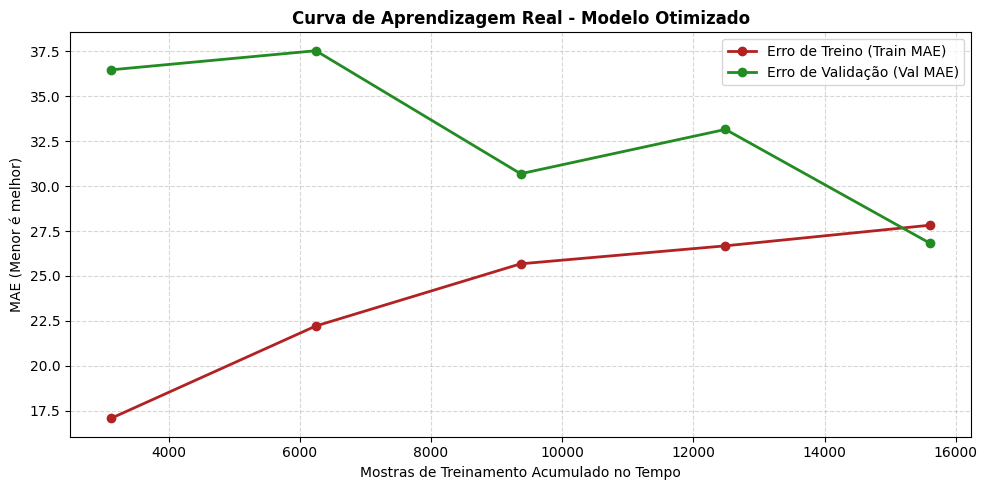

In [ ]:
# 13. Learning curves
# Initialize lists for in-process storage
muestras_entrenamiento = []
train_maes = []
val_maes = []

# Iterate over the actual time windows for dataset growth
for train_idx, val_idx in tscv.split(x_train_ot):

    # Separate training and validation sets for the current fold
    X_tr, X_va = x_train_ot.iloc[train_idx], x_train_ot.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Initialize LightGBM with the best parameters found by Optuna
    # We use a fixed n_estimators // we do not apply early stopping here
    params_curva = best_params_final.copy()
    params_curva['n_estimators'] = 500

    model_fold = lgb.LGBMRegressor(**params_curva, random_state=42, n_jobs=-1)

    # train the model with the accumulated time window up to this fold
    model_fold.fit(X_tr, y_tr)

    # Make predictions on both sets
    preds_train = model_fold.predict(X_tr)
    preds_val = model_fold.predict(X_va)

    # Save the training set size and the MAE values
    muestras_entrenamiento.append(len(X_tr))
    train_maes.append(mean_absolute_error(y_tr, preds_train))
    val_maes.append(mean_absolute_error(y_va, preds_val))

# Plot the temporal learning curve
plt.figure(figsize=(10, 5))

# Training error curve
plt.plot(muestras_entrenamiento, train_maes, marker='o', color='#b22222',
         linewidth=2, label='Erro de Treino (Train MAE)')

# Validation error curve (Green)
plt.plot(muestras_entrenamiento, val_maes, marker='o', color='#228b22',
         linewidth=2, label='Erro de Validação (Val MAE)')

# Curve settings
plt.title('Curva de Aprendizagem Real - Modelo Otimizado',
          fontsize=12, fontweight='bold')
plt.xlabel('Mostras de Treinamento Acumulado no Tempo', fontsize=10)
plt.ylabel('MAE (Menor é melhor)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()

# Show chart
plt.show()